In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torchvision
from transformers import AutoModelForImageClassification

import matplotlib.pyplot as plt

from devinterp.optim import SGLD
from devinterp.slt.sampler import estimate_learning_coeff_with_summary
from devinterp.vis_utils import EpsilonBetaAnalyzer


# Local import:
# import sys
# sys.path.append("../src/devinterp")
# from vis_utils import EpsilonBetaAnalyzer


DEVICE = "cuda:7" if torch.cuda.is_available() else "cpu"


def evaluate(model, data):
    inputs, outputs = data

    return torch.nn.functional.cross_entropy(model(inputs).logits, outputs), {
        "outputs": outputs
    }


# Load a pretrained MNIST classifier
model = AutoModelForImageClassification.from_pretrained("fxmarty/resnet-tiny-mnist")

model.to(DEVICE)

# model.train()

data = torchvision.datasets.MNIST(
    root="../data",
    download=True,
    transform=torchvision.transforms.ToTensor(),
)

batch_size = 256

loader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)

/home/adam/.conda/envs/jax311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# get random batch from loader
inputs, outputs = next(iter(loader))

inputs, outputs = inputs.to(DEVICE), outputs.to(DEVICE)
data = (inputs, outputs)

# evaluate model
loss, _ = evaluate(model, data)

In [4]:
model.train()

ResNetForImageClassification(
  (resnet): ResNetModel(
    (embedder): ResNetEmbeddings(
      (embedder): ResNetConvLayer(
        (convolution): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU()
      )
      (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (encoder): ResNetEncoder(
      (stages): ModuleList(
        (0): ResNetStage(
          (layers): Sequential(
            (0): ResNetBasicLayer(
              (shortcut): ResNetShortCut(
                (convolution): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (normalization): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              )
              (layer): Sequential(
                (0): ResNetConvLayer(
                  (convolution): Conv2d(64, 32, k

In [5]:
loss, _ = evaluate(model, data)
loss

loss.backward()

In [6]:
# gradient_vector as tensor
gradient_vector = torch.cat([p.grad.view(-1) for p in model.parameters()])

In [7]:
gradient_vector.abs().mean()

tensor(0.0008, device='cuda:7')

In [8]:
1e-3

0.001

In [9]:
model.eval()
loss, _ = evaluate(model, data)
loss

tensor(4.2923, device='cuda:0', grad_fn=<NllLossBackward0>)

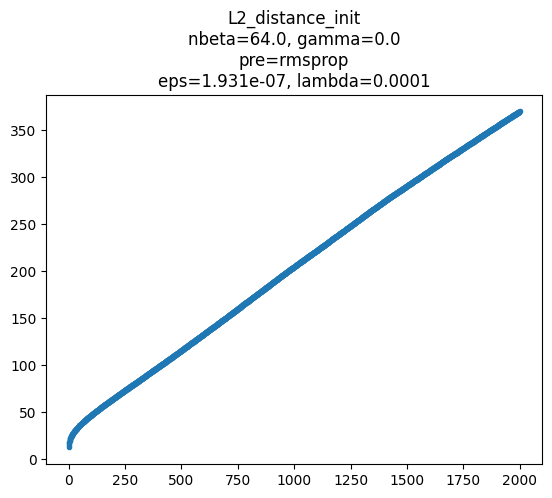

KeyboardInterrupt: 

In [ ]:
from palamedes.sgld_sampler import *

for nbeta in [
    64.0,
    332.0,
    1721.0,
    8913.0,
    46166.0,
]:

    gamma = 0.0

    preconditioner = "rmsprop"

    params = SGLDParams(
        eps=0.00019306977288832496 / 1e3,  # total step size
        gamma=gamma,  # localization term
        batch_size=batch_size,  # batch size
        nbeta=nbeta,  # this is not beta, but beta * n, where n= |whole dataset|
        num_steps=2000,  # number of steps
        checkpoint_every=None,  # If integer, saves weights every checkpoint_every steps
        save_dir=None,  # if not specified, it defaults to /mnt/ssd-1/louis/palamedes/sgld_samples/{current_time}
        # device=device,
        preconditioner=preconditioner,  # "none" or "rmsprop"
        alpha_rmsprop=0.99,  # rmsprop parameter
        lambda_rmsprop=1e-4,  # rmsprop parameter
    )

    sgld_dict = sgld(
        model,
        params,
        dataset=loader,
        cost_fn="cross_entropy",
        device=DEVICE,
        fp16=False,
    )

    for metric in ["L2_distance_init", "loss"]:
        plt.plot(sgld_dict[metric], ".-")
        plt.title(
            f"{metric}\nnbeta={nbeta}, gamma={gamma}\npre={preconditioner}\neps={params.eps:.4g}, lambda={params.lambda_rmsprop:.4g}"
        )
        plt.show()

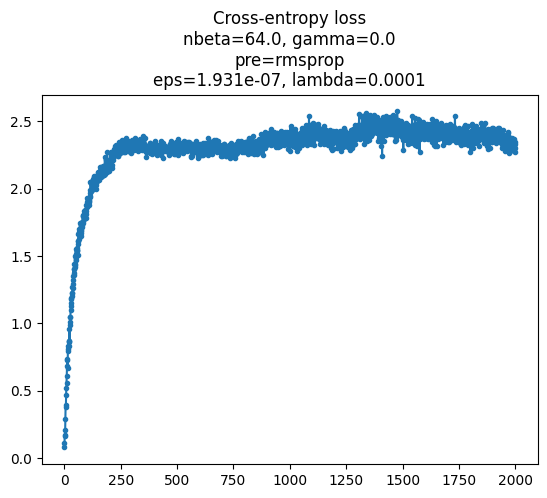

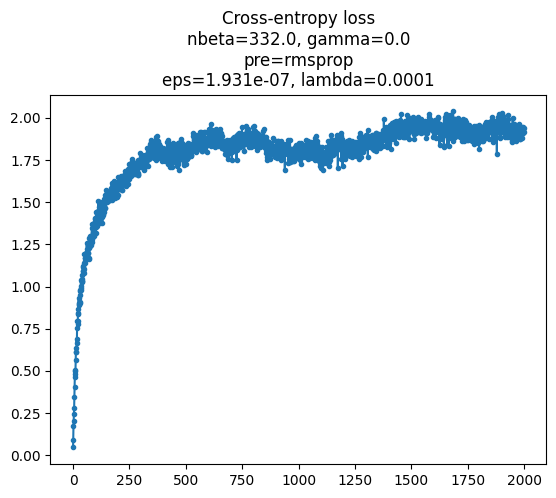

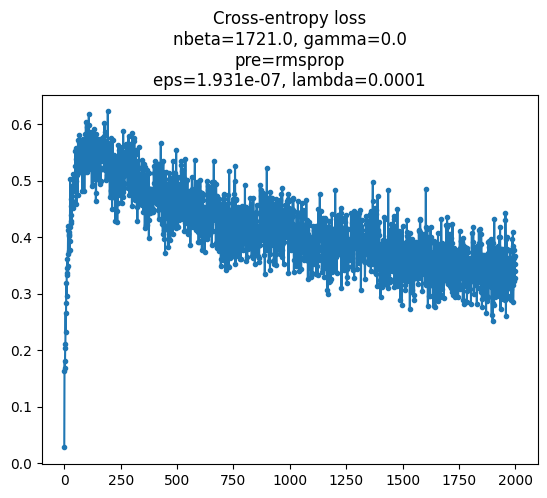

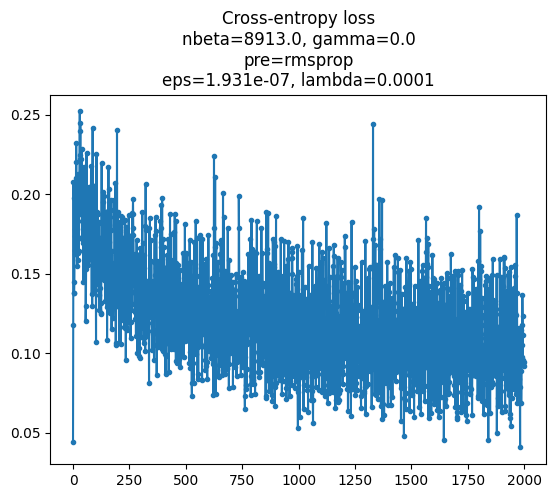

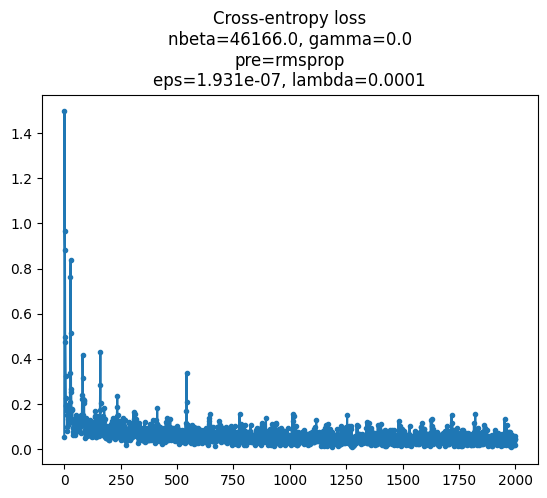

In [2]:
from palamedes.sgld_sampler import *

for nbeta in [
    64.0,
    332.0,
    1721.0,
    8913.0,
    46166.0,
]:

    gamma = 0.0

    preconditioner = "rmsprop"

    params = SGLDParams(
        eps=0.00019306977288832496 / 1e3,  # total step size
        gamma=gamma,  # localization term
        batch_size=batch_size,  # batch size
        nbeta=nbeta,  # this is not beta, but beta * n, where n= |whole dataset|
        num_steps=2000,  # number of steps
        checkpoint_every=None,  # If integer, saves weights every checkpoint_every steps
        save_dir=None,  # if not specified, it defaults to /mnt/ssd-1/louis/palamedes/sgld_samples/{current_time}
        # device=device,
        preconditioner=preconditioner,  # "none" or "rmsprop"
        alpha_rmsprop=0.99,  # rmsprop parameter
        lambda_rmsprop=1e-4,  # rmsprop parameter
    )

    sgld_dict = sgld(
        model,
        params,
        dataset=loader,
        cost_fn="cross_entropy",
        device=DEVICE,
        fp16=False,
    )

    plt.plot(sgld_dict["loss"], ".-")
    plt.title(
        f"Cross-entropy loss\nnbeta={nbeta}, gamma={gamma}\npre={preconditioner}\neps={params.eps:.4g}, lambda={params.lambda_rmsprop:.4g}"
    )
    plt.show()

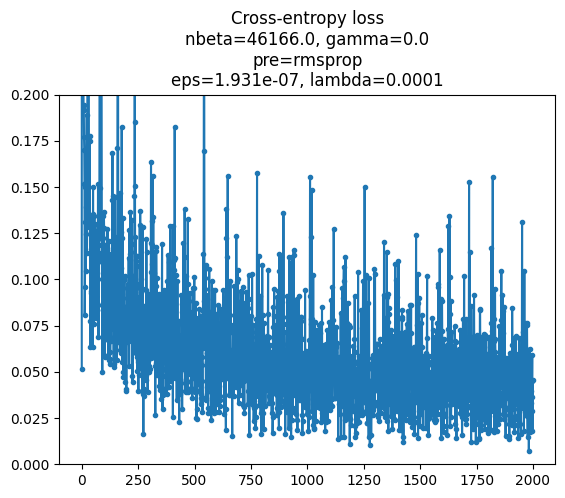

In [3]:
plt.plot(sgld_dict["loss"], ".-")
plt.ylim(0, 0.2)
plt.title(
    f"Cross-entropy loss\nnbeta={nbeta}, gamma={gamma}\npre={preconditioner}\neps={params.eps:.4g}, lambda={params.lambda_rmsprop:.4g}"
)
plt.show()

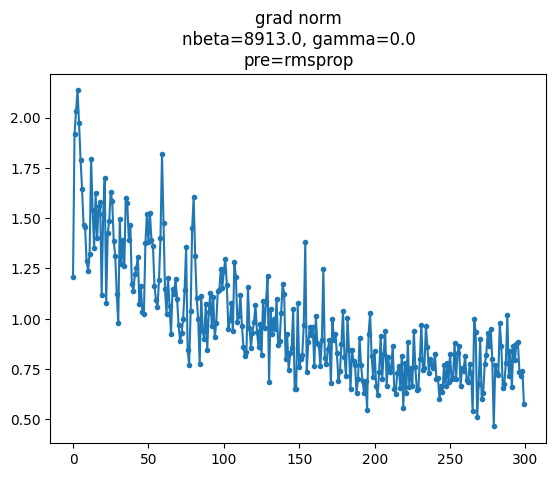

In [24]:
plt.plot(sgld_dict["gradient_norm"], ".-")
plt.title(f"grad norm\nnbeta={nbeta}, gamma={gamma}\npre={preconditioner}")
plt.show()

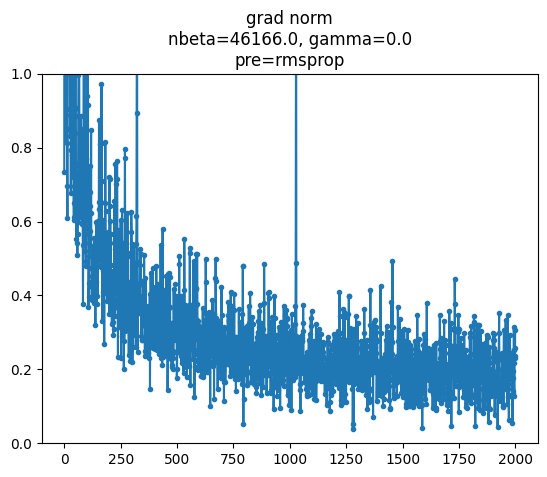

In [28]:
plt.plot(sgld_dict["gradient_norm"], ".-")
plt.ylim(0, 1)
plt.title(f"grad norm\nnbeta={nbeta}, gamma={gamma}\npre={preconditioner}")
plt.show()

In [20]:
0.5 / torch.sqrt(torch.tensor(184074))

tensor(0.0012)

In [26]:
sgld_dict["gradient_norm"][-10:]

[0.1353064775466919,
 0.17641671001911163,
 0.2173769176006317,
 0.3145579397678375,
 0.25368914008140564,
 0.12876255810260773,
 0.2580990195274353,
 0.23735414445400238,
 0.2297629565000534,
 0.30665603280067444]

In [15]:
torch.norm(torch.ones(184074))

tensor(429.0385)

In [17]:
torch.sqrt(torch.tensor(184074))

tensor(429.0385)

In [14]:
torch.nn.utils.parameters_to_vector(model.parameters()).shape

torch.Size([184074])

### Convnext

In [9]:
from tyche.convnext import load_convnext_checkpoint

RUNS_DIR = "/mnt/ssd-1/adam/basin-volume/runs"
models_clean = [
    load_convnext_checkpoint(
        RUNS_DIR + f"/b16pai_p001/checkpoint-{2**(step+1)}", device=DEVICE
    )
    for step in range(15, 16)
]

In [23]:
from tyche.convnext import load_cifar10_splits_dict


cifar10_ds = load_cifar10_splits_dict(size=10000, device=DEVICE)

val_ds = cifar10_ds["val"]
clean_ds = cifar10_ds["clean"]
poisoned_ds = cifar10_ds["poison"]
val_ds_labels = cifar10_ds["val_labels"]
clean_ds_labels = cifar10_ds["clean_labels"]
poisoned_ds_labels = cifar10_ds["poison_labels"]

In [25]:
from jaxtyping import Float

import torch as t


def logit_loss(
    p: Float[t.Tensor, "batch_size d_output"], q: Float[t.Tensor, "batch_size d_output"]
):
    log_p = p - t.logsumexp(p, dim=-1, keepdim=True)  # log softmax of p
    log_q = q - t.logsumexp(q, dim=-1, keepdim=True)  # log softmax of q

    # KL = sum(exp(log_p) * (log_p - log_q))
    return (log_p.exp() * (log_p - log_q)).sum(dim=-1).mean()

In [26]:
def cost_fn(model, data, clean_model):
    logits_init = clean_model(data)["logits"]

    logits = model(inputs)["logits"]
    loss = logit_loss(logits_init, logits)

    return loss

In [27]:
clean_model = models_clean[0]

In [28]:
def cost_fn(model, data):
    global clean_model

    logits_init = clean_model(data)["logits"]
    logits = model(data)["logits"]
    loss = logit_loss(logits_init, logits)

    return loss

In [29]:
from copy import deepcopy
model = deepcopy(clean_model)

In [30]:
loader = torch.utils.data.DataLoader(clean_ds, batch_size=256, shuffle=True)

In [31]:
from devinterp.utils import plot_trace, default_nbeta


In [32]:
default_nbeta(loader)

np.float64(46.16624130844683)

In [55]:

x = estimate_learning_coeff_with_summary(
    model=model,
    loader=loader,
    evaluate=cost_fn,
    optimizer_kwargs=dict(lr=1e-5, localization=0, nbeta=1e4),
    num_chains=1,  # How many independent chains to run
    num_draws=150,  # How many samples to draw per chain
    num_burnin_steps=0,  # How many samples to discard at the beginning of each chain
    num_steps_bw_draws=1,  # How many steps to take between each sample
    device=DEVICE,
)

/home/adam/.conda/envs/jax311/lib/python3.11/site-packages/devinterp/slt/sampler.py:117: UserWarning: Using passed in nbeta. Make sure callbacks are also initialized with the same nbeta.
  warnings.warn(
/home/adam/.conda/envs/jax311/lib/python3.11/site-packages/devinterp/backends/default/slt/sampler.py:240: UserWarning: You are taking more draws than burn-in steps, your LLC estimates will likely be underestimates. Please check LLC chain convergence.
  warnings.warn(
/home/adam/.conda/envs/jax311/lib/python3.11/site-packages/devinterp/backends/default/slt/sampler.py:244: UserWarning: You are taking more sample batches than there are dataloader batches available, this removes some randomness from sampling but is probably fine. (All sample batches beyond the number dataloader batches are cycled from the start, f.e. 9 samples from [A, B, C] would be [B, A, C, B, A, C, B, A, C].)
  warnings.warn(
/home/adam/.conda/envs/jax311/lib/python3.11/site-packages/devinterp/backends/default/slt/samp

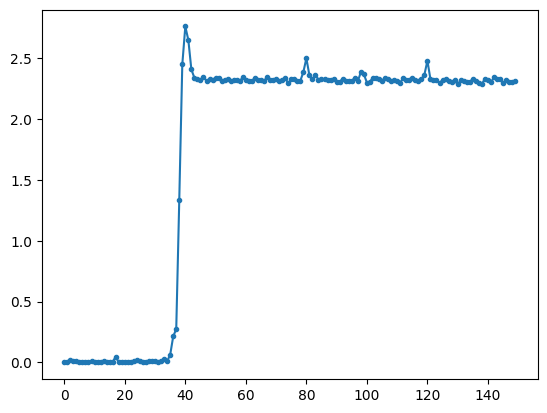

In [56]:
for trace in x['loss/trace']:
    plt.plot(trace, ".-")
plt.show()


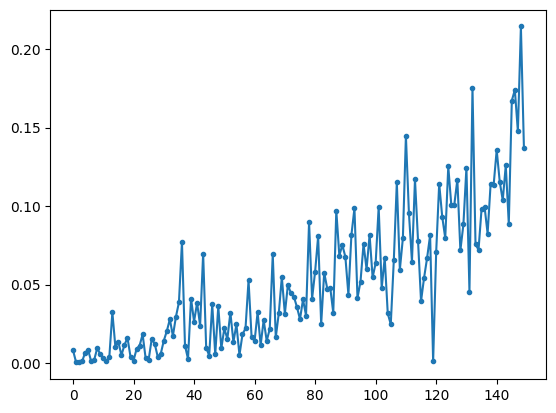

In [48]:
for trace in x['loss/trace']:
    plt.plot(trace, ".-")
plt.show()


In [19]:
loader = torch.utils.data.DataLoader(clean_ds, batch_size=256, shuffle=True)
list(iter(loader))[0].shape

torch.Size([256, 3, 32, 32])

In [33]:
datapoints = list(zip(clean_ds, clean_ds_labels))

In [34]:
both_loader = torch.utils.data.DataLoader(datapoints, batch_size=256, shuffle=True)

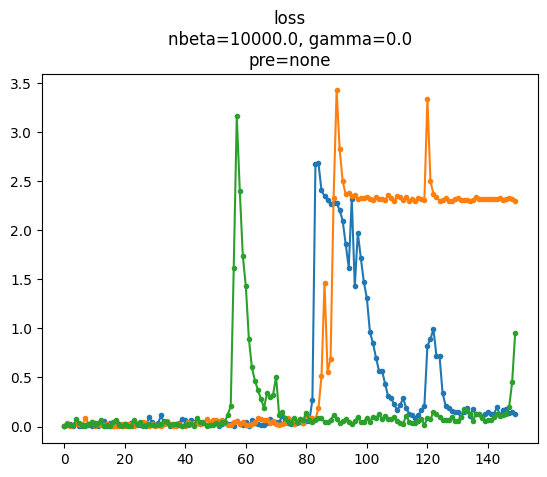

In [57]:
from palamedes.sgld_sampler import *
nbeta = default_nbeta(loader)

metric = "loss"

for chain in range(3):

    params = SGLDParams(
        eps=1e-5,  # total step size
        gamma=0.,  # localization term
        batch_size=batch_size,  # batch size
        nbeta=1e4,  # this is not beta, but beta * n, where n= |whole dataset|
        num_steps=150,  # number of steps
        checkpoint_every=None,  # If integer, saves weights every checkpoint_every steps
        save_dir=None,  # if not specified, it defaults to /mnt/ssd-1/louis/palamedes/sgld_samples/{current_time}
        # device=device,
        preconditioner="none",  # "none" or "rmsprop"
        alpha_rmsprop=0.99,  # rmsprop parameter
        lambda_rmsprop=1e-4,  # rmsprop parameter
    )

    sgld_dict = sgld(
        model,
        params,
        dataset=both_loader,
        cost_fn="KL",
        device=DEVICE,
        fp16=True,
    )

    plt.plot(sgld_dict[metric], ".-")

plt.title(
    f"{metric}\nnbeta={params.nbeta}, gamma={params.gamma}\npre={params.preconditioner}" + \
    (f"\neps={params.eps:.4g}, lambda={params.lambda_rmsprop:.4g}" if params.preconditioner == "rmsprop" else "")
)
plt.show()